###Context
* You're working at BCG as Data Scientist
* Your team has been assigned a new project for a client called PowerCo
* Your client is PowerCo - a major gas and electricity utility that supplies to small and medium sized enterprises.
* The energy market has had a lot of change in recent years and there are more options than ever for customers to choose from.
* PowerCo are concerned about their customers leaving for better offers from other energy providers. When a customer leaves to use another service provider, this is called churn.
* This is becoming a big issue for PowerCo and they have engaged BCG to help diagnose the reason why their customers are churning.
* Some potential reasons for this churn, one being how “sensitive” the price is. In other words, how much is price a factor in a customer’s choice to stay with or leave PowerCo?

In order to test the hypothesis of whether churn is driven by the customers’ price sensitivity, we would need to model churn probabilities of customers, and derive the effect of prices on churn rates.

We would need the following data to be able to build the models.

* Customer data - which should include characteristics of each client, for example, industry, historical electricity consumption, date joined as customer etc.
* Churn data - which should indicate if customer has churned
* Historical price data – which should indicate the prices the client charges to each customer for both electricity and gas at granular time intervals


Once we have the data, the work plan would be:

* We need to define what price sensitivity is and calculate it
* We need to prepare the data and engineer features
* Then, we can test our hypothesis using a binary classification model (e.g. Logistic Regression, Random Forest, Gradient Boosted Machines to name a few)
* We would choose a model from one of the tested algorithms based on the model complexity, the explainability, and the accuracy of the models.
* With the trained model, we would be able to extrapolate the extent to which price sensitivity influences churn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

###EDA and Data Cleaning

Next task will be to investigate whether price sensitivity is the most influential factor for a customer churning, and if not, to what extent price sensitivity influences churn.


Before we begin on this task, it is important that we are clear about what we mean when we talk about price sensitivity.

* **Price sensitivity** is the degree to which customer behaviors change in response to a change in price. In other words, how much do PowerCo’s customers react when prices go up?

Sensitivity is often quantified using the price elasticity of demand formula which is [% change in quantity demanded / % change in price].

As a general rule, if the absolute value of the price elasticity of demand formula is greater than 1, the product or service would be considered elastic meaning that the price is very likely to influence how much people buy.

* **Price elasticity** of demand is a measurement of the change in consumption of a product in relation to a change in its price

The data provided by the client are:

* **Historical customer data**: Customer data such as usage, sign up date, forecasted usage etc
* **Historical pricing data**: variable and fixed pricing data at different points in time
* **Churn indicator**: whether each customer has churned or not

In [ ]:
client_data = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/client_data.csv')
price_data = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/price_data.csv')

In [ ]:
client_df = client_data.copy()
price_df = price_data.copy()

In [ ]:
client_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0


In [ ]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [ ]:
client_df.select_dtypes(include=object).describe()

,id,channel_sales,date_activ,date_end,date_modif_prod,date_renewal,has_gas,origin_up
count,14606,14606,14606,14606,14606,14606,14606,14606
unique,14606,8,1796,368,2129,386,2,6
top,563dde550fd624d7352f3de77c0cdfcd,foosdfpfkusacimwkcsosbicdxkicaua,2009-08-01,2016-02-01,2015-11-01,2015-06-23,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,95,145,721,587,11955,7097


In [ ]:
#Find the MISSING category of channel sales
client_df['channel_sales'].value_counts()

,count
channel_sales,
foosdfpfkusacimwkcsosbicdxkicaua,6754
MISSING,3725
lmkebamcaaclubfxadlmueccxoimlema,1843
usilxuppasemubllopkaafesmlibmsdf,1375
ewpakwlliwisiwduibdlfmalxowmwpci,893
sddiedcslfslkckwlfkdpoeeailfpeds,11
epumfxlbckeskwekxbiuasklxalciiuu,3
fixdbufsefwooaasfcxdxadsiekoceaa,2


In [ ]:
#Convert dates into "datetime64" format from object
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])
client_df['date_modif_prod'] = pd.to_datetime(client_df['date_modif_prod'])
client_df['date_renewal'] = pd.to_datetime(client_df['date_renewal'])

In [ ]:
#Create a function that plots stacked barchart
def plot_stacked_bars(dataframe,title_,size_=(18,10),rot_=0,legend="upper right"):
  ax = dataframe.plot(
      kind='bar',
      stacked=True,
      figsize=size_,
      rot=rot_,
      title=title_
  )

  annotate_stacked_bars(ax,textsize=14)
  plt.legend(["Retention","Churn"],loc=legend)
  plt.ylabel("Company Base (%)")
  plt.show()


def annotate_stacked_bars(ax,pad=0.99,color="white",textsize=13):
  for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=color,
            size=textsize
        )

In [ ]:
#Plot stacked bar chart for churn

churn = client_df[['id','churn']]
churn.columns = ['Companies','churn'] #rename the columns
churn_total = churn.groupby(churn['churn']).count() #counts no. of churn for each company
churn_percentage = churn_total / churn_total.sum() * 100  #churn% = churn / sum(churn) * 100

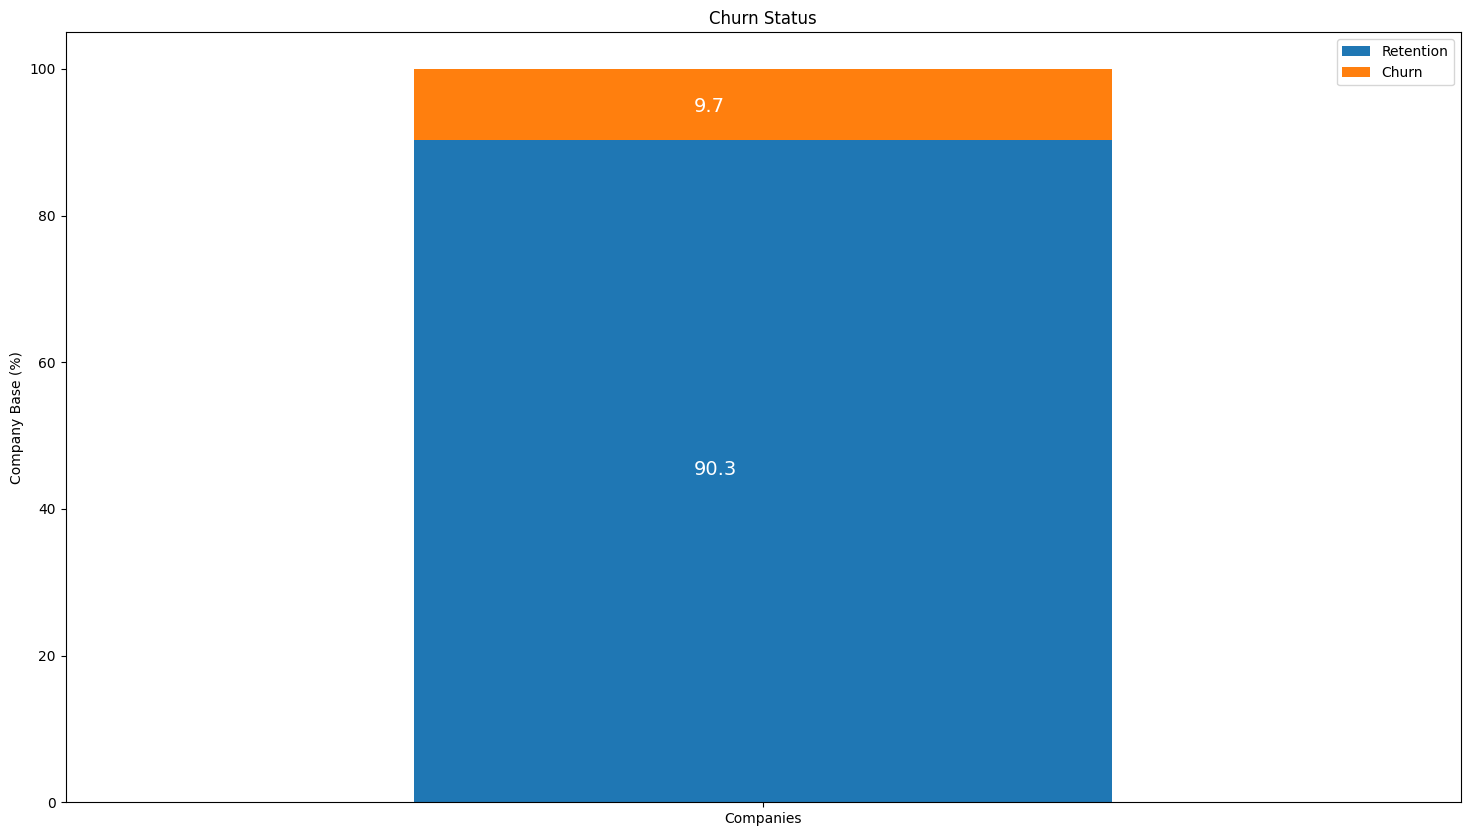

In [ ]:
plot_stacked_bars(churn_percentage.transpose(),"Churn Status")

About 10% of the total customers have churned

In [ ]:
#Plot stacked bar chart for Sales channel
channel = client_df[["id","channel_sales","churn"]]
channel = channel.groupby([channel['channel_sales'],channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1),axis=0) * 100).sort_values(by=[1],ascending=False)

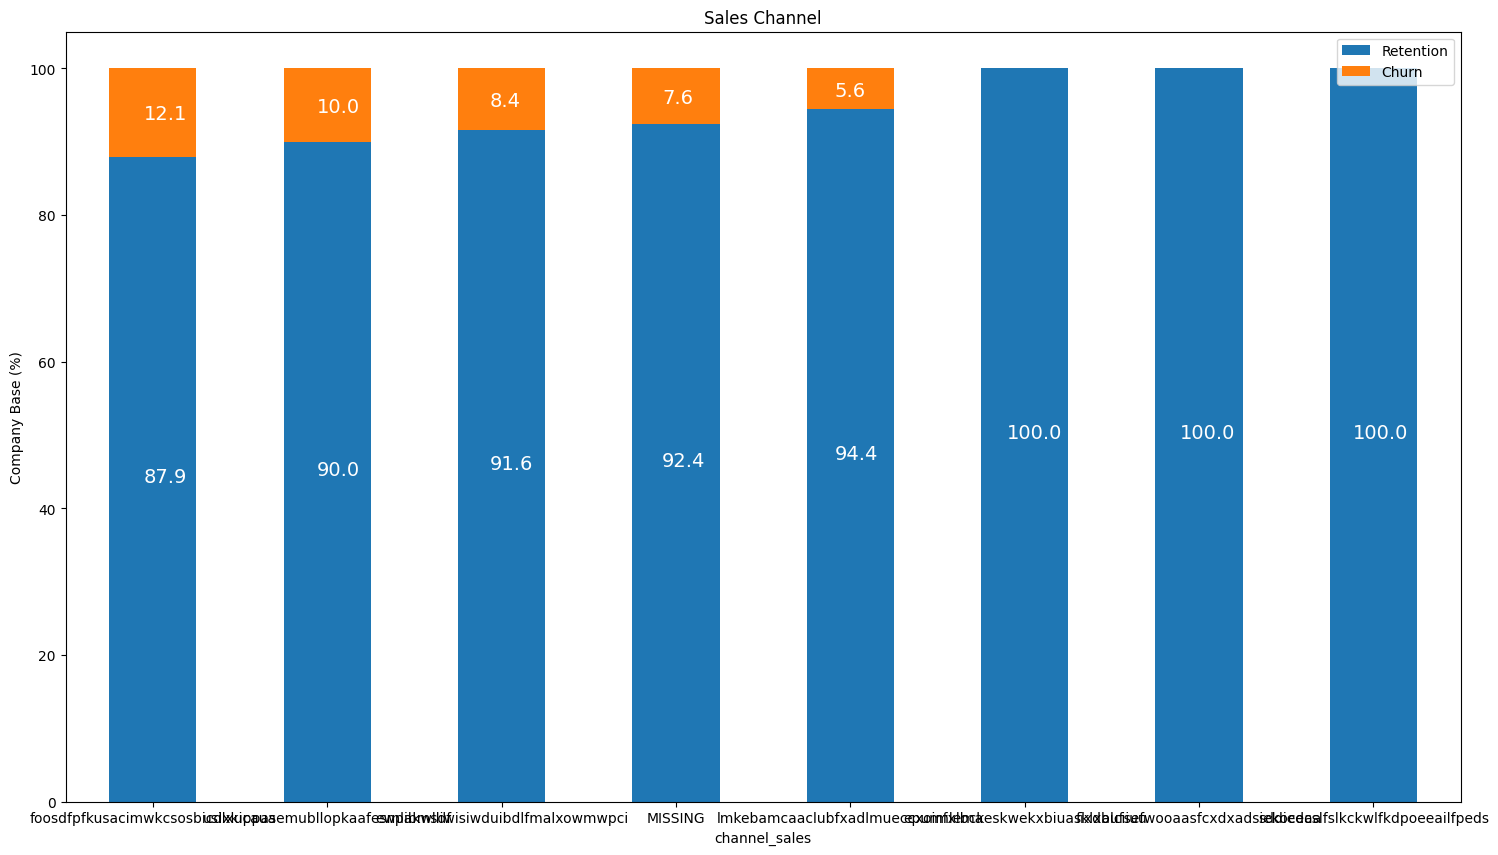

In [ ]:
plot_stacked_bars(channel_churn,"Sales Channel")

Churning customers are distributed over 5 different values for `channel_sales`.

`MISSING` has churn rate of 7.6% --> indicates that missing value was added by the team when theu were cleanig the dataset

In [ ]:
#Since consumption data is univariate , we use histogram to plot their distribution
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [ ]:
#Create a function that plots variable distribution in a stacked histogram of churned or retained company

def plot_distribution(dataframe,column,ax,bins_=50):
  #create the temporal df that contains the data to be plot
  temp = pd.DataFrame({"Retention":dataframe[dataframe["churn"]==0][column],
                       "Churn":dataframe[dataframe["churn"]==1][column]})
  #Plot the histogram
  temp[["Retention","Churn"]].plot(kind="hist",bins=bins_,ax=ax,stacked=True)
  ax.set_xlabel(column)
  #Chnage the x-axis to plain style
  ax.ticklabel_format(style='plain',axis='x')

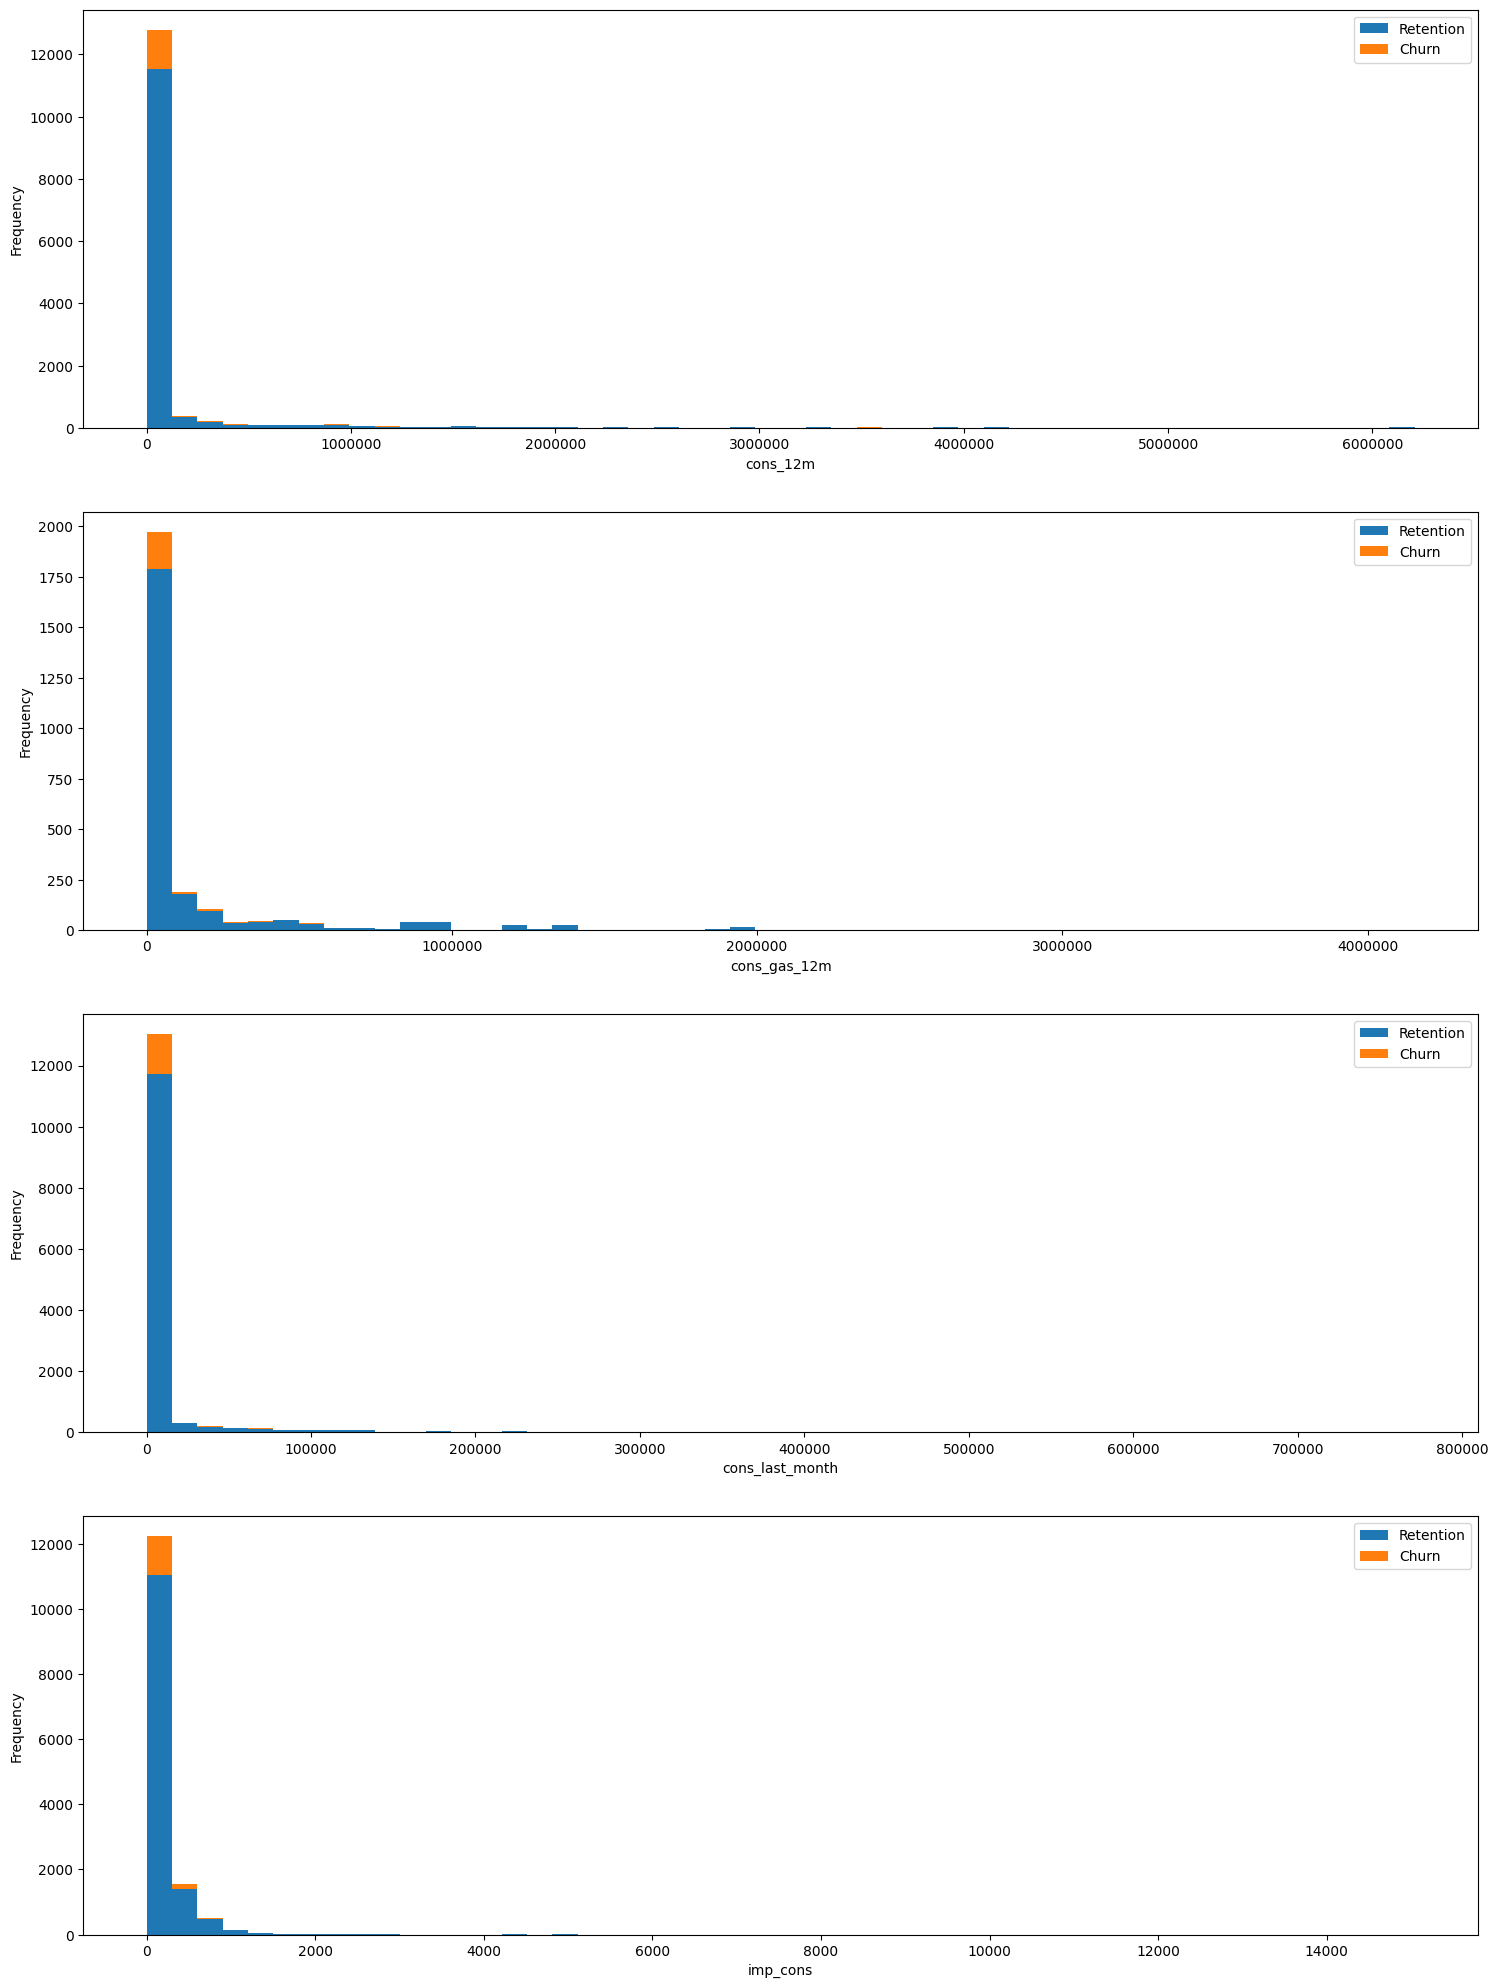

In [ ]:
fig,axs = plt.subplots(nrows=4,figsize=(18,25))

plot_distribution(consumption,"cons_12m",axs[0])
plot_distribution(consumption[consumption["has_gas"]=='t'],'cons_gas_12m',axs[1])
plot_distribution(consumption,'cons_last_month',axs[2])
plot_distribution(consumption,'imp_cons',axs[3])

Clearly, the consumption data is positively skewed, presenting a very long right-tail towards the higher-values of the distribution.

The values on the lower end are likely ro be outliers

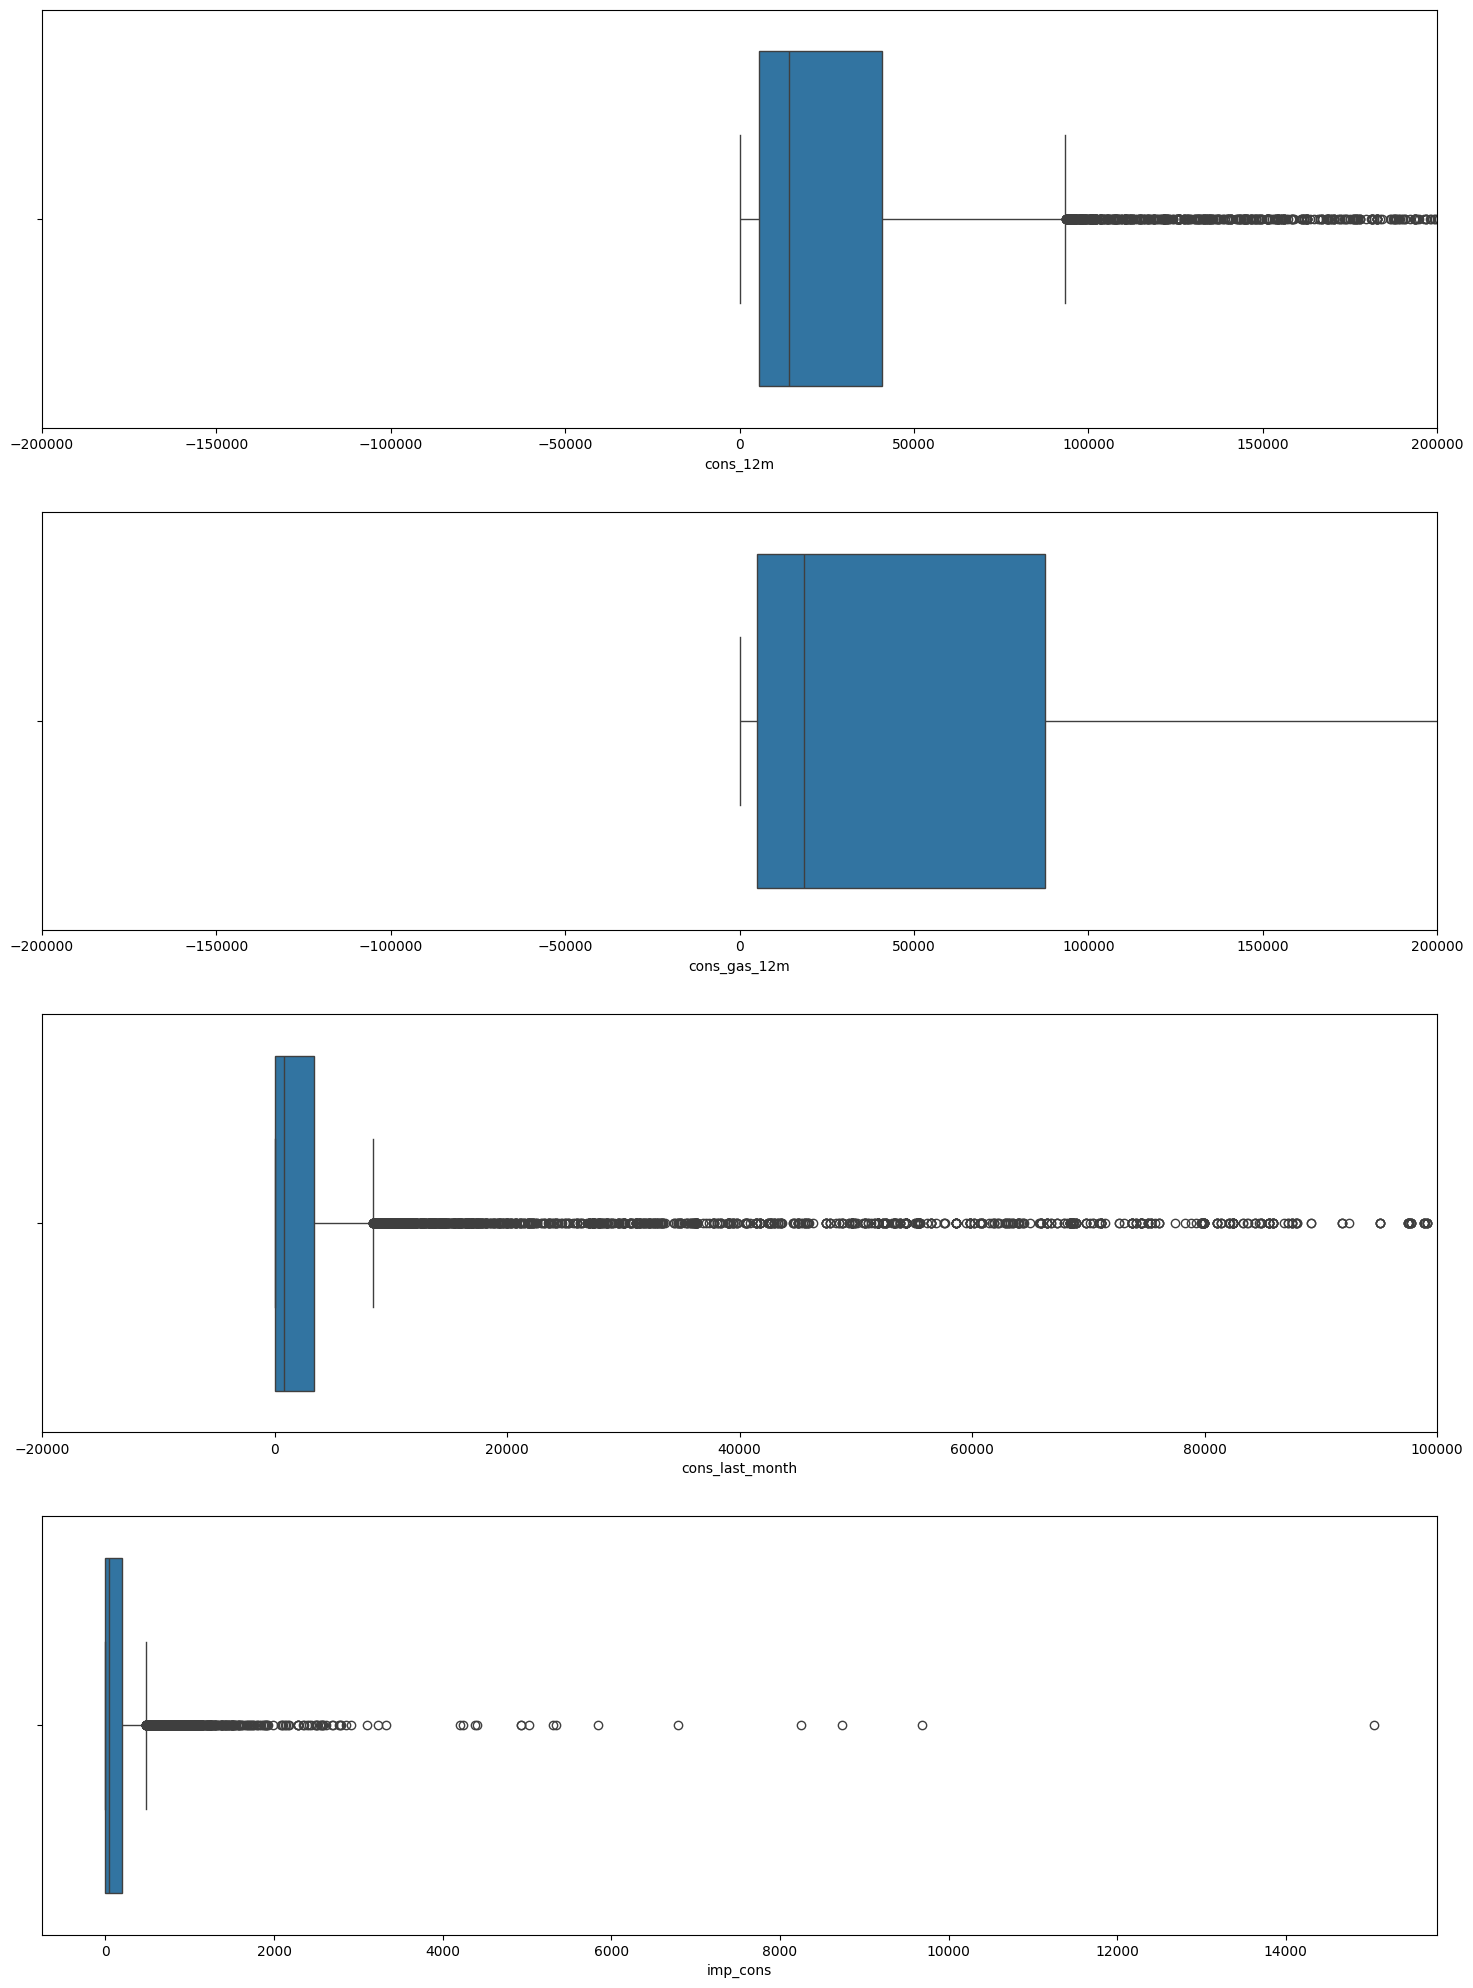

In [ ]:
#Create boxplots to reveal any possible outliers
fig,axs = plt.subplots(nrows=4,figsize=(18,25))

sns.boxplot(x="cons_12m", data=consumption, ax=axs[0])
sns.boxplot(x='cons_gas_12m', data=consumption[consumption["has_gas"]=='t'], ax=axs[1])
sns.boxplot(x='cons_last_month', data=consumption, ax=axs[2])
sns.boxplot(x='imp_cons', data=consumption, ax=axs[3])

#Remove scientific notations
for ax in axs:
  ax.ticklabel_format(style='plain',axis='x')
  #set x-axis limit
  axs[0].set_xlim(-200000,200000)
  axs[1].set_xlim(-200000,200000)
  axs[2].set_xlim(-20000,100000)

plt.show()

Thes outliers will be dealt with in feature engineering part

---



In [ ]:
#Forecast data is univariate , we use histogram to plot their distribution
forecast = client_df[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn"
    ]
]

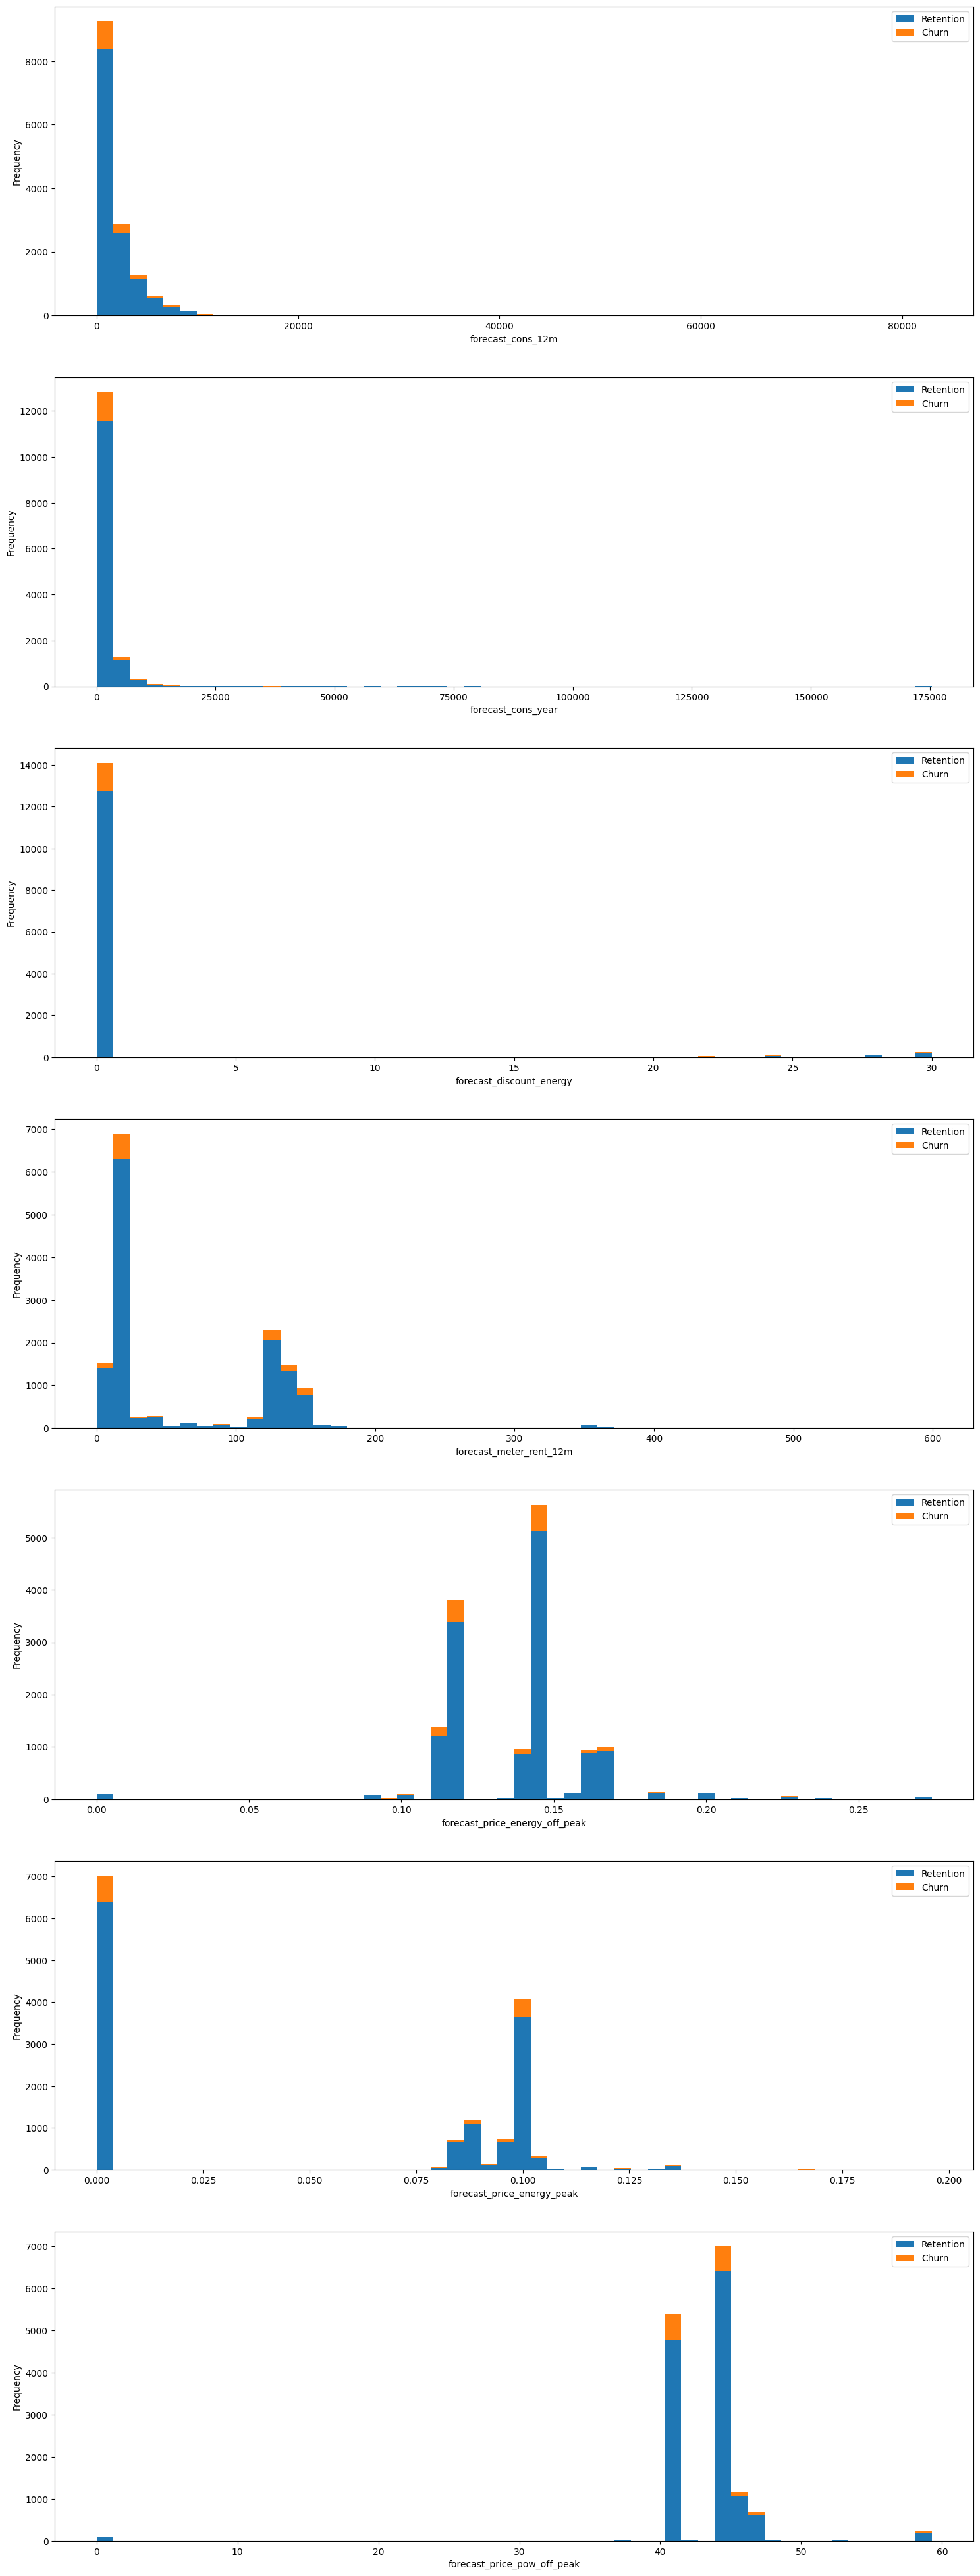

In [ ]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

# Plot histogram
plot_distribution(client_df, "forecast_cons_12m", axs[0])
plot_distribution(client_df, "forecast_cons_year", axs[1])
plot_distribution(client_df, "forecast_discount_energy", axs[2])
plot_distribution(client_df, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_df, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_df, "forecast_price_energy_peak", axs[5])
plot_distribution(client_df, "forecast_price_pow_off_peak", axs[6])

Some portion of the data has skewness, which will be fixed in the feature engineering section

In [ ]:
# Plot stacked bar chart for Contract Type

contract_type = client_df[["id","has_gas","churn"]]
contract = contract_type.groupby([contract_type['churn'],contract_type['has_gas']])['id'].count().unstack(level=0)
contract_percentage = (contract.div(contract.sum(axis=1),axis=0)*100).sort_values(by=[1],ascending=False)

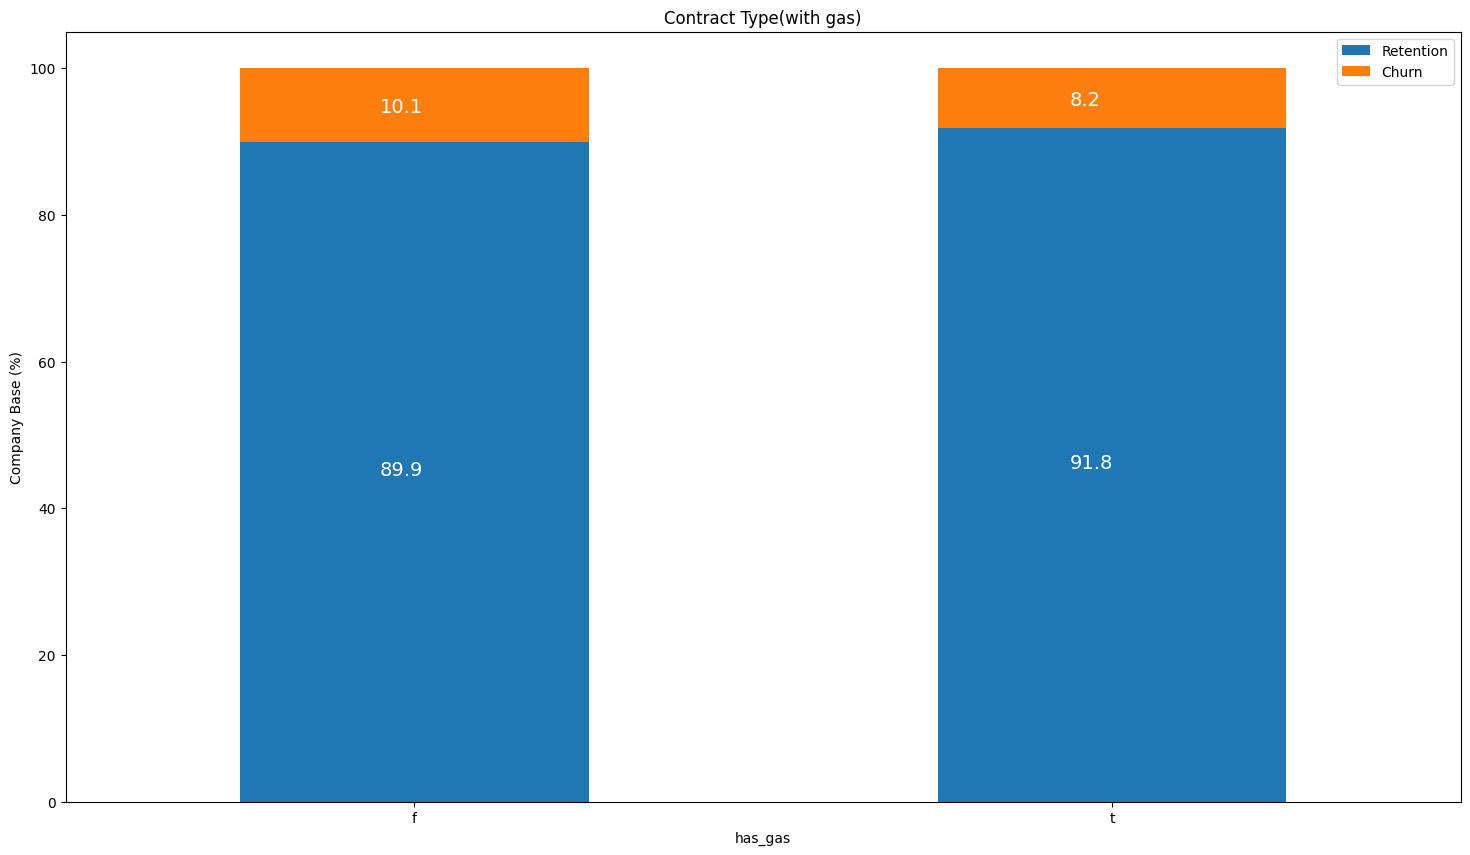

In [ ]:
plot_stacked_bars(contract_percentage,'Contract Type(with gas)')

In [ ]:
#Create boxplots to reveal any possible outliers
margin = client_df[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

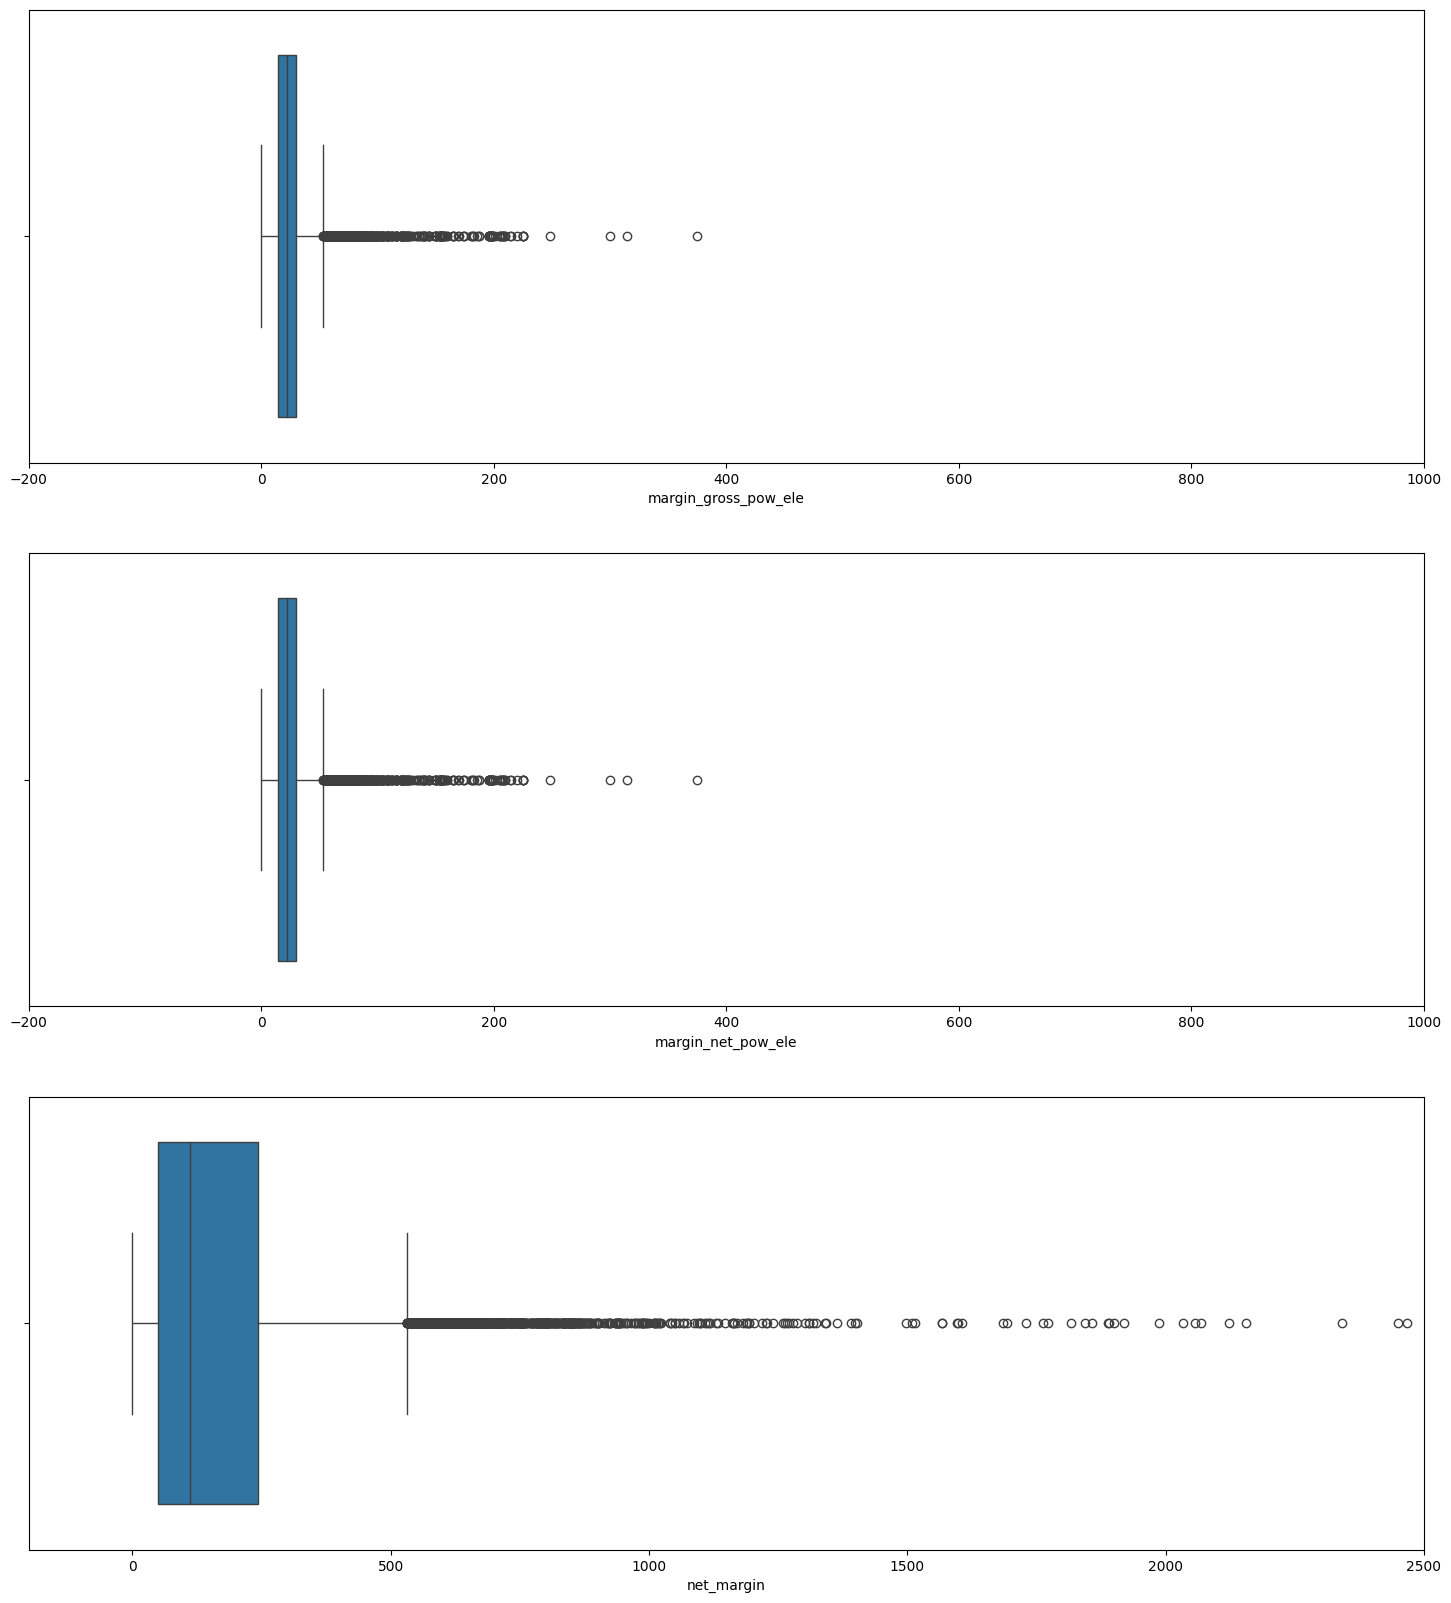

In [ ]:
fig,axs = plt.subplots(nrows=3,figsize=(18,20))

sns.boxplot(x=margin["margin_gross_pow_ele"],ax=axs[0])
sns.boxplot(x=margin["margin_net_pow_ele"],ax=axs[1])
sns.boxplot(x=margin["net_margin"],ax=axs[2])

#Remove scientific notation
for ax in axs:
  ax.ticklabel_format(style='plain',axis='x')

#set x-axis limit
axs[0].set_xlim(-200, 1000)
axs[1].set_xlim(-200, 1000)
axs[2].set_xlim(-200, 2500)

plt.show()

These outliers will also be dealt with later

In [ ]:
#Plot histogram to visualize distribution of Subscribed power
power = client_df[["id","pow_max","churn"]]

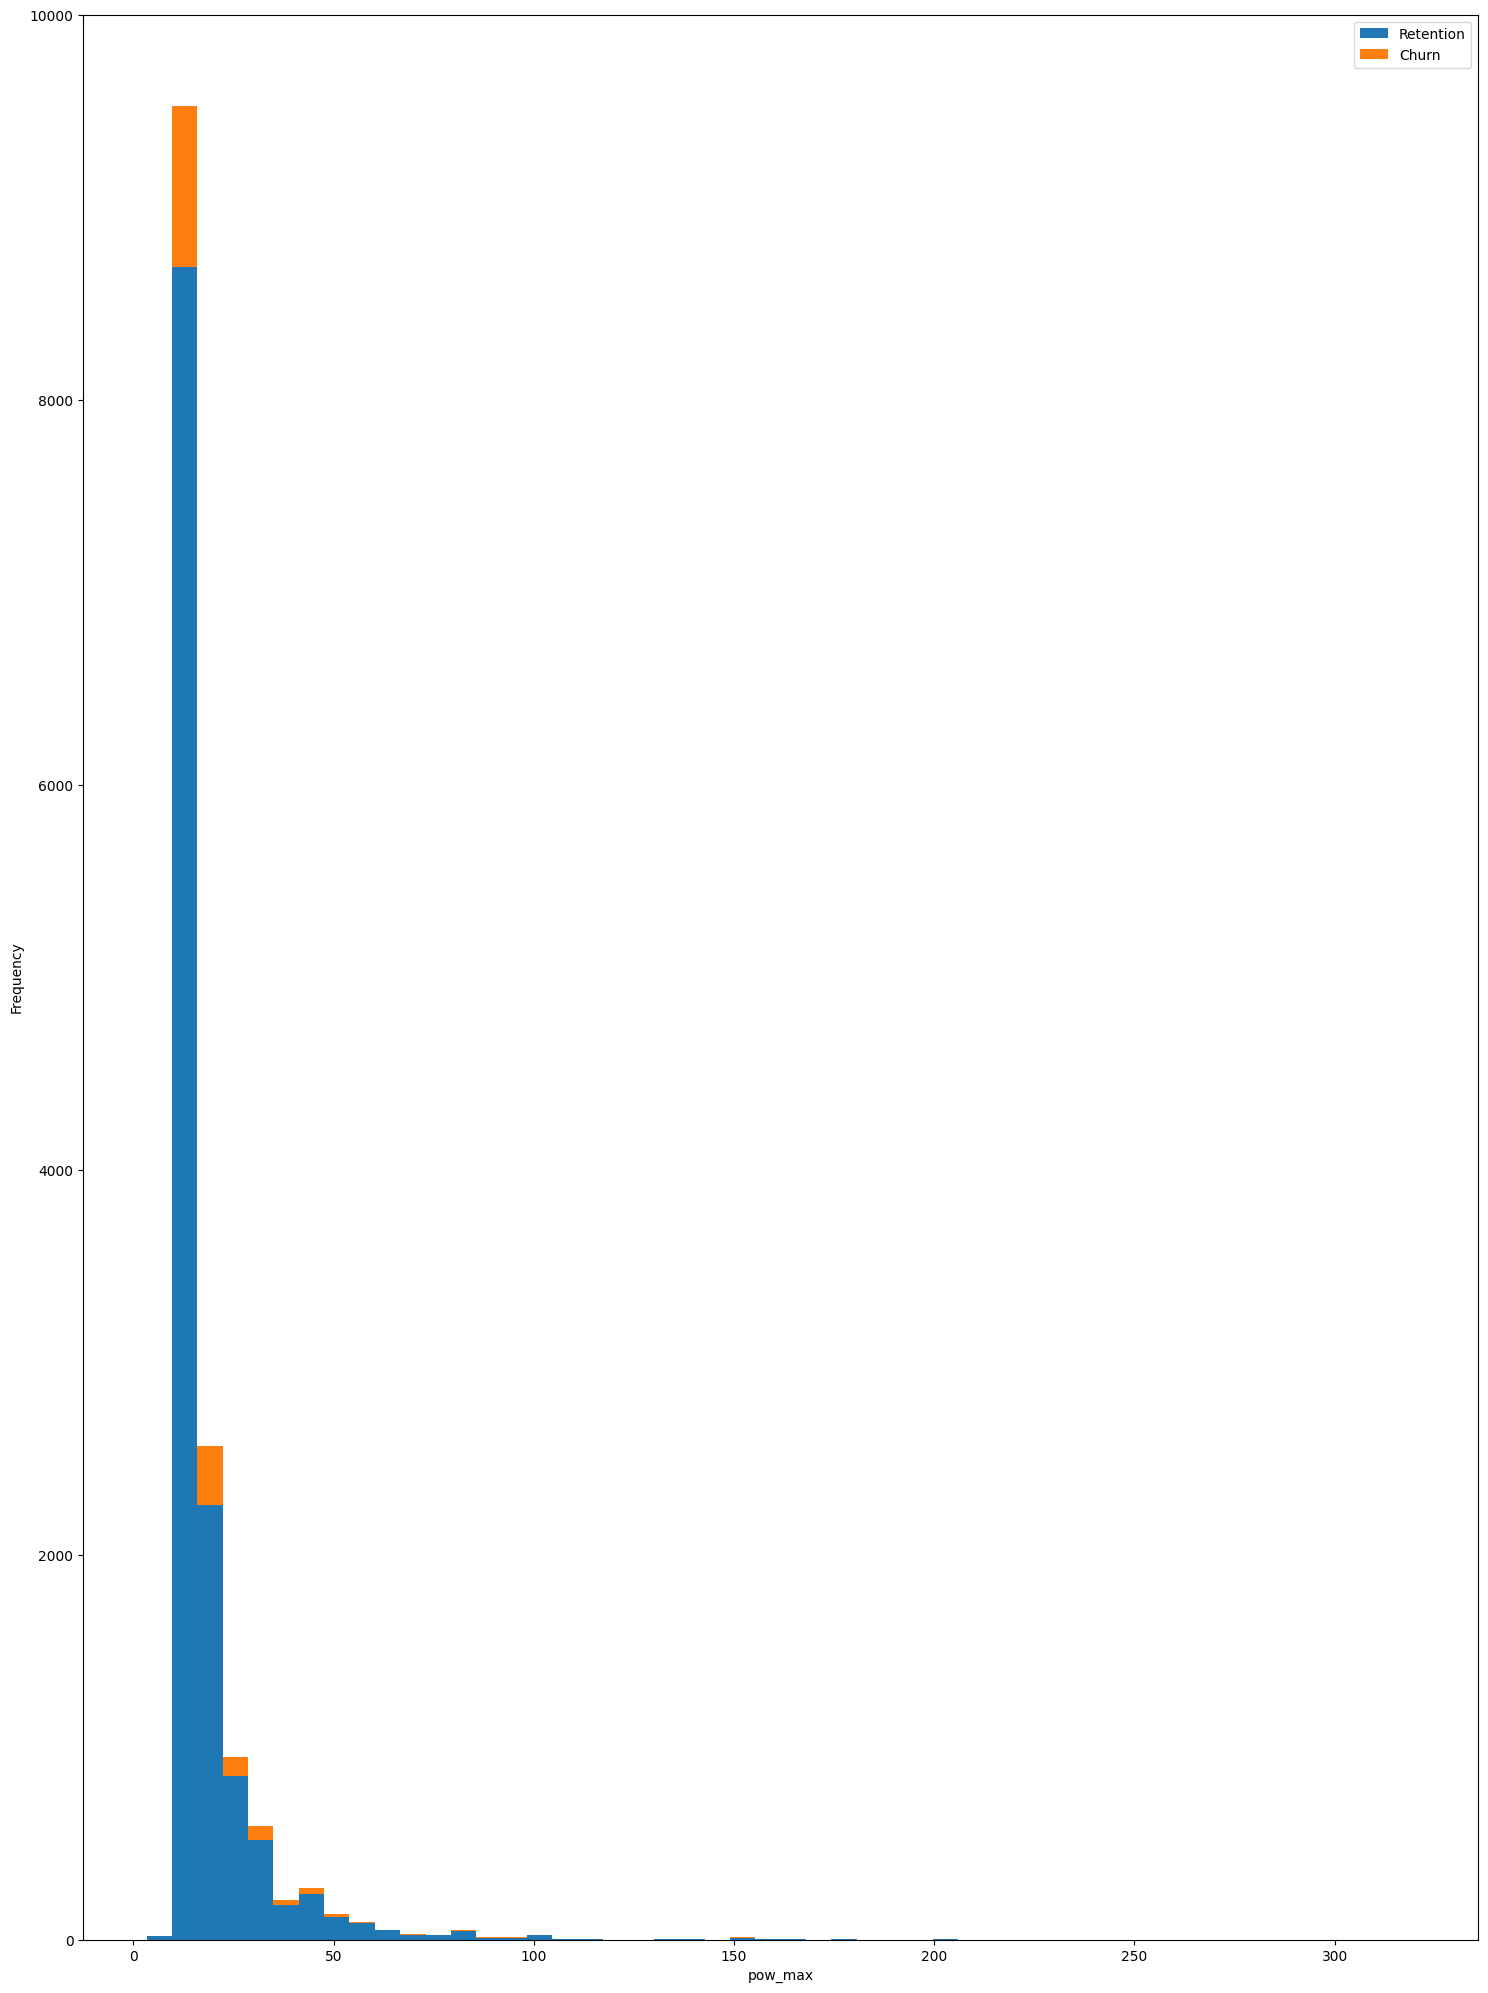

In [ ]:
fig,axs = plt.subplots(nrows=1,figsize=(18,25))
plot_distribution(power,"pow_max",axs)

In [ ]:
#Plotting other columns
others = client_df[['id','num_years_antig','nb_prod_act','origin_up','churn']]

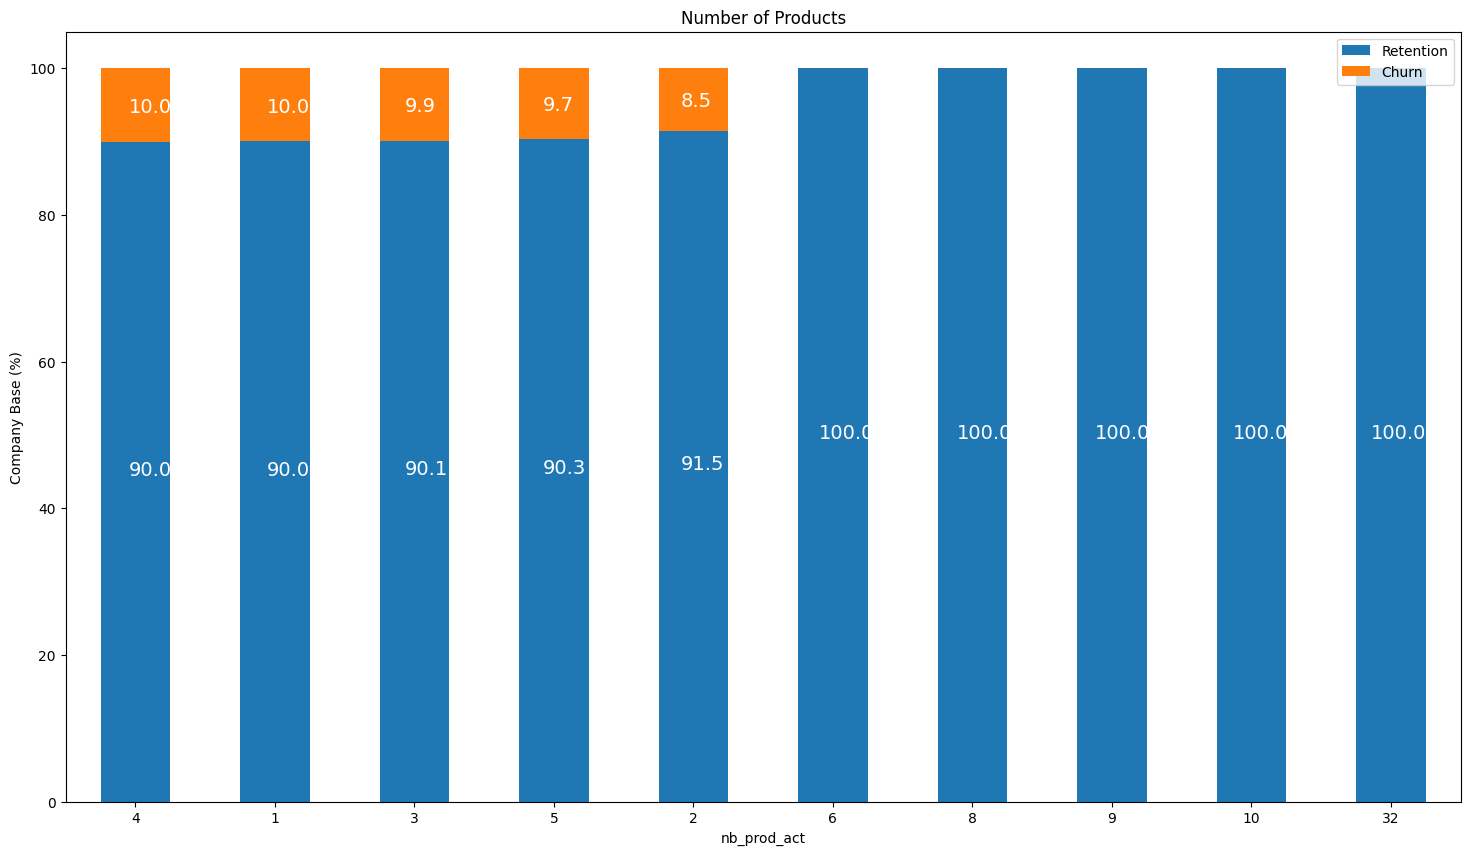

In [ ]:
#Plotting stacked bar charts for products
products = others.groupby([others['nb_prod_act'],others['churn']])['id'].count().unstack(level=1)
product_percentage = (products.div(products.sum(axis=1),axis=0)*100).sort_values(by=[1],ascending=False)
plot_stacked_bars(product_percentage,"Number of Products")

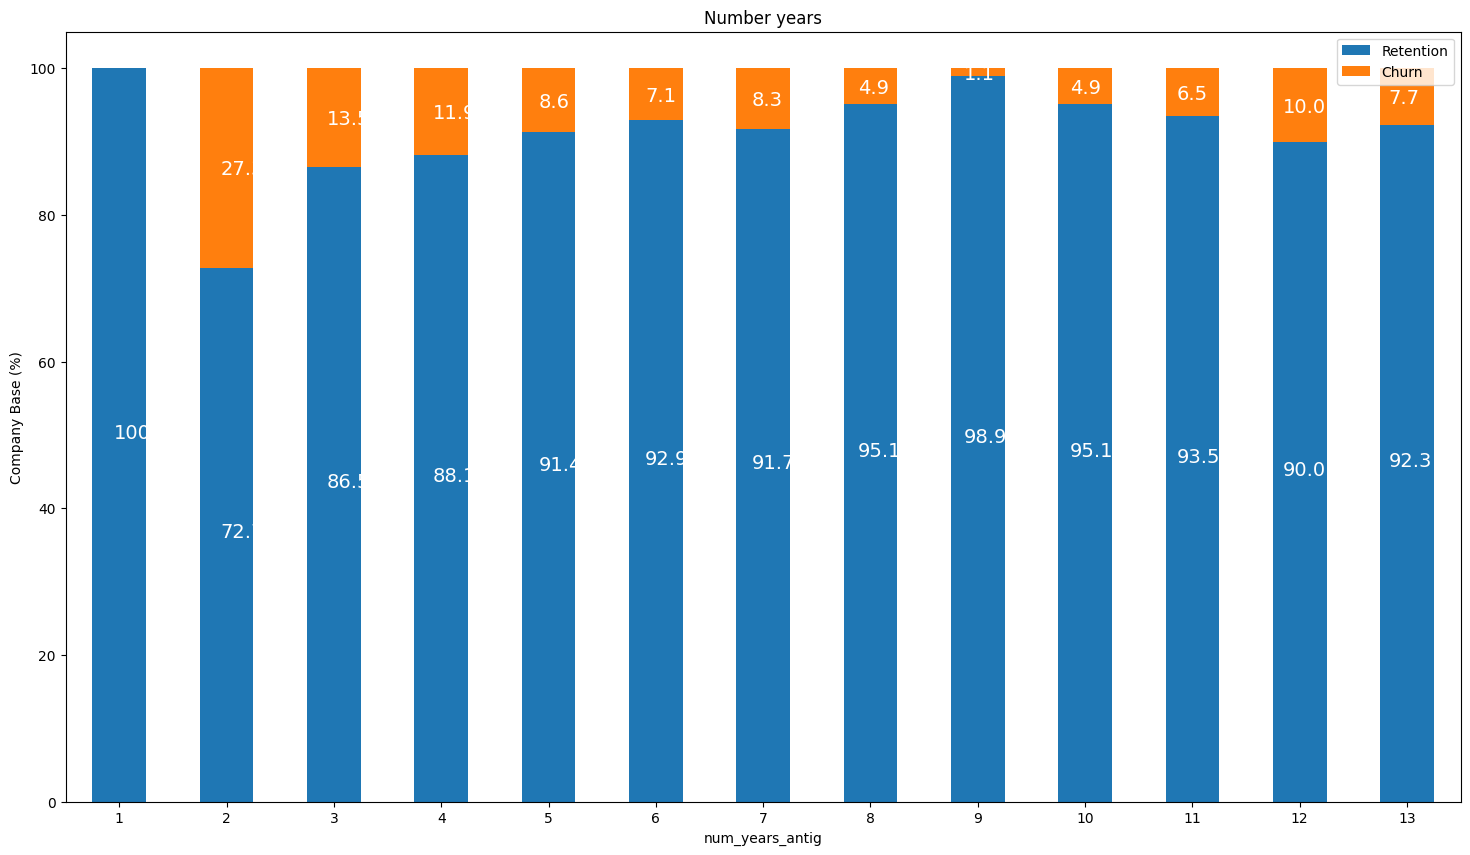

In [ ]:
#Plotting stacked bar charts for number years
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

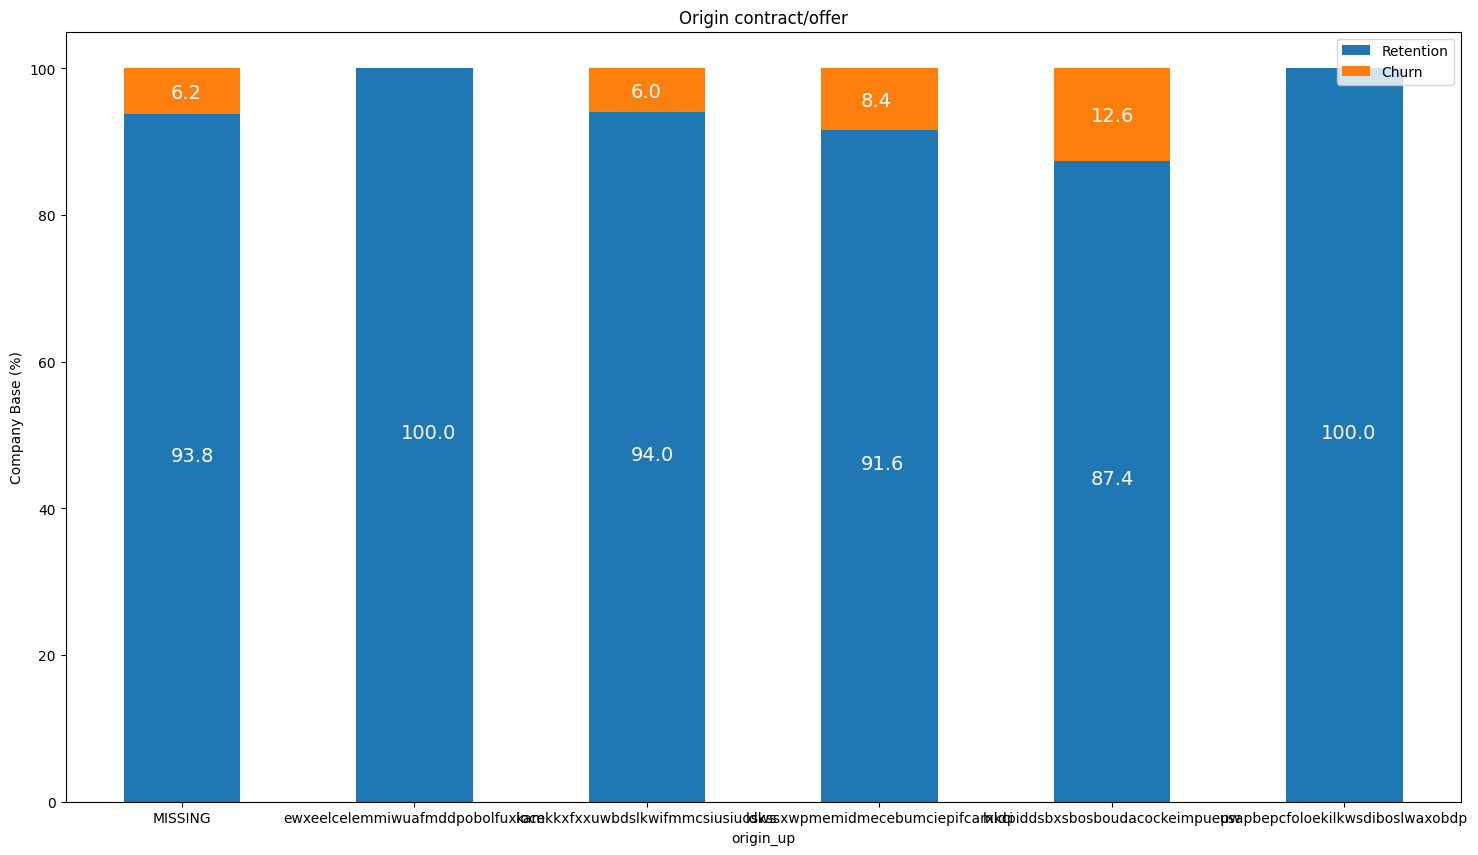

In [ ]:
#Plotting stacked bar charts for products
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")

In [ ]:
price_df

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
...,...,...,...,...,...,...,...,...
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


In [ ]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [ ]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


###Analysis Report from EDA

* These visualizations show how many companies churned vs. how many companies did not churn. We can see from this that the churn rate is approximately 10%. This is actually a very good churn rate – the closer the rate is to 0%, the better.
* The next series of visualizations were created in an attempt to dive deeper into how churn changes based on other factors (using other columns). This is useful for us to investigate because it may help us to understand factors that drive churn.
* We've also visualized churn vs. sales channel, contract type, number of products, number of years and origin/contract offer.
* We see that for sales channel, there are some sales channels that yield customers churning but there are also other sales channels that have no customers churning.
* For contract type, we see quite an even split for customers churning. This is interesting because this may suggest that contract type is not a driving factor towards churn rate.
* We notice that the distribution of consumption is very skewed, this is called a positive skew since it is biased towards lower values on the x axis.
* This is interesting because you may decide to transform this column to reduce the skewness later on during feature engineering. In addition, you may want to check for outliers in this column.
* To investigate outliers, we use a boxplot. From the boxplot we can see that with the column as it is there are definitely some outliers. Once again, this is interesting because we may choose to remove some of these outliers later.